Importación de bibliotecas necesarias

In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.6 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 3.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 3.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 3.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.4 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 3.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 3.4 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 3.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 3.5 MB/s eta 0:00:01
   ----------------

In [6]:
pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.1 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [8]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Cargar los datos de ejemplo (20 SPAM y 20 HAM)

Primero, vamos a crear un conjunto de datos de ejemplo con 20 mensajes de SPAM y 20 mensajes de HAM.

In [10]:
# Datos de ejemplo
spam_messages = [
    "¡Felicidades, has ganado un millón de dólares! Solo necesitas enviar tu información.",
    "¡Compra ahora y gana un viaje gratis a las islas Bahamas!",
    "Este es un mensaje importante, ¡tu cuenta bancaria ha sido hackeada!",
    "Tienes una oferta especial que expira en 24 horas, ¡aprovecha ahora!",
    "¡URGENTE! Tu cuenta ha sido suspendida, haz clic para solucionar.",
    "No olvides que hoy termina el descuento del 90% en productos electrónicos.",
    "¡Actúa rápido! Te ofrecemos un préstamo personal sin intereses.",
    "Compra ahora y te daremos un bono de 500 dólares.",
    "Solo hoy, si compras 2 productos te damos otro gratis.",
    "El premio que has solicitado está disponible solo por 48 horas, actúa rápido.",
    "Es tu última oportunidad para ganar un teléfono móvil de última generación.",
    "Haz clic aquí para ganar dinero desde casa sin esfuerzo.",
    "¡Increíble oferta! Invierte en criptomonedas ahora.",
    "Es tu última oportunidad para cambiar tus boletos de avión gratis.",
    "¡Haz clic ahora y recibe tu tarjeta de regalo de 100 dólares!",
    "¡Sorpresa! Has sido seleccionado para una oportunidad única.",
    "Alerta: Alguien ha intentado acceder a tu cuenta. Cambia tu contraseña ahora.",
    "Recibe alertas en tiempo real sobre las mejores ofertas de productos.",
    "Gana dinero fácilmente, solo ingresa a nuestro sitio web.",
    "Tienes un mensaje pendiente en tu bandeja de entrada, abrelo ahora."
]

ham_messages = [
    "Hola, ¿cómo estás? ¿Cuándo nos vemos?",
    "¿Puedes enviarme el informe de ayer?",
    "Voy a estar fuera de la oficina hasta el viernes, te contestaré luego.",
    "Feliz cumpleaños, espero que tengas un gran día.",
    "¿Qué opinas del artículo que compartí contigo?",
    "Nos vemos el sábado para la reunión, ¿te parece bien?",
    "¿Te gustaría ir al cine este fin de semana?",
    "¿Puedes revisar el documento que te envié el lunes?",
    "Gracias por tu ayuda con el proyecto, ¡nos vemos pronto!",
    "¿Nos encontramos en el restaurante a las 7 PM?",
    "¡Qué tal! Te llamé ayer, pero no pude comunicarme contigo.",
    "Recuerda que tenemos una reunión el miércoles a las 10 AM.",
    "¿Podrías ayudarme a organizar los archivos en la carpeta?",
    "Te invito a la fiesta de cumpleaños este fin de semana.",
    "¿A qué hora llegas al trabajo mañana?",
    "Gracias por tus comentarios sobre mi presentación.",
    "Hoy tengo una cita con el dentista, pero en la tarde estoy libre.",
    "¿A qué hora sale el tren para la ciudad?",
    "Nos vemos el próximo mes en la conferencia.",
    "El informe está listo, ¿quieres que te lo envíe por correo?"
]

# Crear el DataFrame
data = spam_messages + ham_messages
labels = ['spam'] * len(spam_messages) + ['ham'] * len(ham_messages)
df = pd.DataFrame({'message': data, 'label': labels})

df.head()

,message,label
0,"¡Felicidades, has ganado un millón de dólares!...",spam
1,¡Compra ahora y gana un viaje gratis a las isl...,spam
2,"Este es un mensaje importante, ¡tu cuenta banc...",spam
3,Tienes una oferta especial que expira en 24 ho...,spam
4,"¡URGENTE! Tu cuenta ha sido suspendida, haz cl...",spam


Procesamiento y limpieza de los datos

Ahora vamos a limpiar los datos eliminando URLs, menciones de usuarios, caracteres especiales y más.

In [11]:
# Función de limpieza de texto
def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar URLs
    text = re.sub(r'http\S+', '', text)
    # Eliminar menciones (@usuario)
    text = re.sub(r'@[\w]+', '', text)
    # Eliminar caracteres especiales y números
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text)
    return text

# Aplicar la función de limpieza a todos los mensajes
df['cleaned_message'] = df['message'].apply(clean_text)

df.head()

,message,label,cleaned_message
0,"¡Felicidades, has ganado un millón de dólares!...",spam,felicidades has ganado un millón de dólares so...
1,¡Compra ahora y gana un viaje gratis a las isl...,spam,compra ahora y gana un viaje gratis a las isla...
2,"Este es un mensaje importante, ¡tu cuenta banc...",spam,este es un mensaje importante tu cuenta bancar...
3,Tienes una oferta especial que expira en 24 ho...,spam,tienes una oferta especial que expira en horas...
4,"¡URGENTE! Tu cuenta ha sido suspendida, haz cl...",spam,urgente tu cuenta ha sido suspendida haz clic ...


Tokenización y eliminación de stopwords

Usamos la librería nltk para realizar la tokenización y eliminar las palabras vacías (stopwords).

In [12]:
# Descargar stopwords de nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Función para eliminar stopwords
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

# Aplicar la eliminación de stopwords
df['cleaned_message'] = df['cleaned_message'].apply(remove_stopwords)

df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\l\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,message,label,cleaned_message
0,"¡Felicidades, has ganado un millón de dólares!...",spam,felicidades ganado millón dólares solo necesit...
1,¡Compra ahora y gana un viaje gratis a las isl...,spam,compra ahora gana viaje gratis islas bahamas
2,"Este es un mensaje importante, ¡tu cuenta banc...",spam,mensaje importante cuenta bancaria sido hackeada
3,Tienes una oferta especial que expira en 24 ho...,spam,oferta especial expira horas aprovecha ahora
4,"¡URGENTE! Tu cuenta ha sido suspendida, haz cl...",spam,urgente cuenta sido suspendida haz clic soluci...


Vectorización con TF-IDF

Para convertir el texto limpio en vectores numéricos, usaremos la técnica TF-IDF (Term Frequency-Inverse Document Frequency).

In [13]:
# Inicializar el vectorizador TF-IDF
vectorizer = TfidfVectorizer()

# Convertir el texto limpio en vectores TF-IDF
X = vectorizer.fit_transform(df['cleaned_message'])
y = df['label']

División en conjuntos de entrenamiento y prueba

Ahora dividimos los datos en conjuntos de entrenamiento y prueba.

In [14]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((32, 168), (8, 168))

Entrenamiento del modelo Naive Bayes

Entrenamos el modelo Naive Bayes usando MultinomialNB.

In [15]:
# Inicializar el clasificador Naive Bayes
model = MultinomialNB()

# Entrenar el modelo
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Evaluación del modelo

Evaluamos el modelo usando precisión, recall, y F1-score. También mostramos la matriz de confusión.

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         3
        spam       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



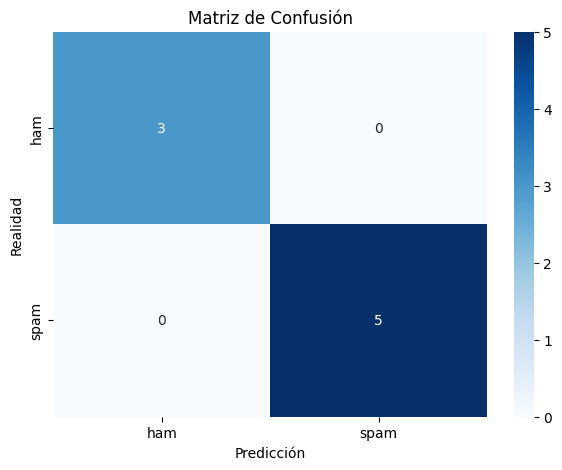

In [16]:
# Predecir las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)

# Generar el reporte de clasificación
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

Predicciones en tiempo real

Puedes usar el modelo para predecir si un mensaje es SPAM o HAM, y mostrar el nivel de confianza.

In [17]:
# Función para hacer predicciones en tiempo real
def predict_message(message):
    cleaned_message = clean_text(message)
    cleaned_message = remove_stopwords(cleaned_message)
    vectorized_message = vectorizer.transform([cleaned_message])
    prediction = model.predict(vectorized_message)
    prediction_prob = model.predict_proba(vectorized_message)
    return prediction[0], prediction_prob.max()

# Ejemplo de predicción
test_message = "¡Felicidades, has ganado un premio! Haz clic aquí para reclamarlo."
prediction, confidence = predict_message(test_message)

print(f"Predicción: {prediction} (Confianza: {confidence:.2f})")

Predicción: spam (Confianza: 0.69)


In [18]:
import joblib

# Guardar el modelo y el vectorizador
joblib.dump(model, 'naive_bayes_spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']